In [3]:
import mlflow
# print("MLflow 버전:", mlflow.__version__)

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")

학습 데이터: (120, 4), 테스트 데이터: (30, 4)


In [6]:
mlflow.set_tracking_uri("http://localhost:5000")  # MLflow 서버 주소
mlflow.set_experiment("iris-jupyter")             # 실험 이름
print("실험 설정 완료!")

2026/03/24 11:44:35 INFO mlflow.tracking.fluent: Experiment with name 'iris-jupyter' does not exist. Creating a new experiment.


실험 설정 완료!


In [11]:
### Train

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 이 값을 바꿔가며 여러 번 실행해보세요 
n_estimators = 100
max_depth = 3

with mlflow.start_run():
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, "model")

    print(f"Accuracy: {acc:.4f}")
    print(f"결과 확인: http://localhost:5000")

2026/03/24 11:46:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 11:46:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 1.0000
결과 확인: http://localhost:5000
🏃 View run languid-midge-716 at: http://localhost:5000/#/experiments/480180226310319022/runs/c50b5b0b03e0405d8044bdd4e5b223b4
🧪 View experiment at: http://localhost:5000/#/experiments/480180226310319022


🏃 View run n=10 at: http://localhost:5000/#/experiments/300656463995733726/runs/20dd5ffc4f1344be910777d613de14a2
🧪 View experiment at: http://localhost:5000/#/experiments/300656463995733726
🏃 View run n=50 at: http://localhost:5000/#/experiments/300656463995733726/runs/1b8637e2c1f24f3296f8b3e4a824ea04
🧪 View experiment at: http://localhost:5000/#/experiments/300656463995733726
🏃 View run n=100 at: http://localhost:5000/#/experiments/300656463995733726/runs/279172065b5745d9b44d8a785bb4bf64
🧪 View experiment at: http://localhost:5000/#/experiments/300656463995733726
🏃 View run n=200 at: http://localhost:5000/#/experiments/300656463995733726/runs/a09e520c4d884bc79a8be1c35a96622f
🧪 View experiment at: http://localhost:5000/#/experiments/300656463995733726


C:\Users\win\anaconda3\envs\mlops\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\win\anaconda3\envs\mlops\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\win\anaconda3\envs\mlops\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\win\anaconda3\envs\mlops\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\win\anaconda3\envs\mlops\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s

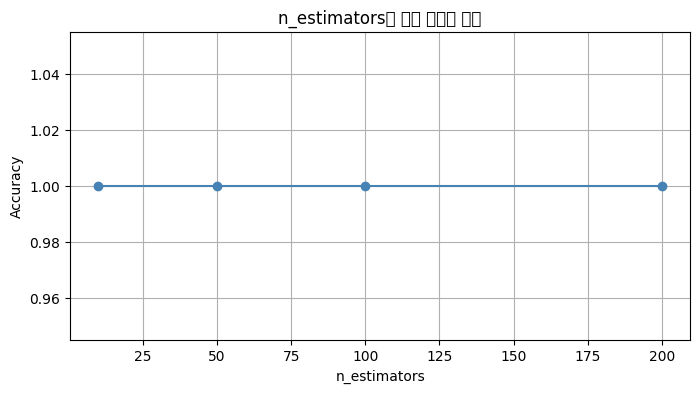

In [5]:
### Local Visualization

import matplotlib.pyplot as plt
import numpy as np

# n_estimators를 바꿔가며 결과 비교
results = []
for n in [10, 50, 100, 200]:
    with mlflow.start_run(run_name=f"n={n}"):
        m = RandomForestClassifier(n_estimators=n, random_state=42)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        mlflow.log_param("n_estimators", n)
        mlflow.log_metric("accuracy", acc)
        results.append((n, acc))

# 그래프
ns, accs = zip(*results)
plt.figure(figsize=(8, 4))
plt.plot(ns, accs, marker='o', color='steelblue')
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("n_estimators에 따른 정확도 변화")
plt.grid(True)
plt.show()


In [9]:
import joblib
import os

# 1. 모델 저장 폴더 생성
os.makedirs("models", exist_ok=True)

# 2. scikit-learn 모델을 파일로 저장
joblib.dump(model, "models/model.pkl")
print("모델 파일 저장 완료: models/model.pkl")

모델 파일 저장 완료: models/model.pkl


In [12]:
%%writefile app.py
from fastapi import FastAPI
import uvicorn
import joblib
import numpy as np
from pydantic import BaseModel

# 1. 입력 데이터 규격 정의 (MLflow Signature 대용)
class IrisInput(BaseModel):
    features: list  # 예: [5.1, 3.5, 1.4, 0.2]

app = FastAPI()

# 2. 서버 시작 시 모델 로드 (상대 경로 주의)
model = joblib.load("models/model.pkl")

@app.get("/")
def root():
    return {"message": "Iris Classification API is running!"}

@app.post("/predict")
def predict(data: IrisInput):
    # 데이터를 모델 입력에 맞게 변환 (1, 4)
    input_data = np.array(data.features).reshape(1, -1)
    prediction = model.predict(input_data)
    
    species = ["setosa", "versicolor", "virginica"]
    return {
        "prediction": int(prediction[0]),
        "species": species[int(prediction[0])]
    }

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)

Writing app.py


In [13]:
%%writefile requirements.txt
fastapi
uvicorn
joblib
scikit-learn
numpy

Writing requirements.txt


In [14]:
%%writefile Dockerfile
# 1. 파이썬 3.9 환경 이미지 사용
FROM python:3.9-slim

# 2. 컨테이너 내부의 작업 폴더 설정
WORKDIR /app

# 3. 필요한 파일들을 컨테이너 안으로 복사
# (현재 폴더의 requirements.txt, app.py, models 폴더를 컨테이너의 /app으로 복사)
COPY requirements.txt .
COPY app.py .
COPY models/ ./models/

# 4. 패키지 설치
RUN pip install --no-cache-dir -r requirements.txt

# 5. API 서버가 사용할 8000번 포트 개방
EXPOSE 8000

# 6. 컨테이너 실행 시 서버 시작 명령어
CMD ["python", "app.py"]

Writing Dockerfile


In [2]:
import requests

# 1. 서버 생존 확인
try:
    health_check = requests.get("http://localhost:8000/")
    print("서버 응답:", health_check.json())
except Exception as e:
    print("서버에 연결할 수 없습니다. Docker 실행 상태를 확인하세요.")

# 2. 실제 예측 요청 (꽃잎/꽃받침 데이터 전달)
sample_data = {"features": [5.1, 3.5, 1.4, 0.2]}  # Setosa 샘플 데이터
response = requests.post("http://localhost:8000/predict", json=sample_data)

if response.status_code == 200:
    print("예측 결과:", response.json())
else:
    print("에러 발생:", response.text)

서버 응답: {'message': 'Iris Classification API is running!'}
예측 결과: {'prediction': 0, 'species': 'setosa'}


In [ ]:
#### Github 올리기

In [3]:
%%writefile .gitignore
# 데이터 (DVC가 관리하므로 Git은 무시)
data/data.csv

# 모델 파일 (선택사항: 너무 크면 제외)
models/*.pkl

# 가상환경 및 캐시
__pycache__/
.ipynb_checkpoints/
venv/
.env

# MLflow 로그
mlruns/

Writing .gitignore


In [ ]:
### g